In [1]:
from typing_extensions import TypedDict
from langgraph.graph import START,END,StateGraph
from IPython.display import display, Image

from typing import Literal


In [2]:
class Data(TypedDict):
    name: str
    game: Literal["cricket","Basketball"]

In [15]:
def playgame(state:Data):
    print("-- Playgame Node call --")
    return {"name":state['name'] + " want to play "}

In [5]:
def cricket(state:Data):
    print("==Cricket callled==")
    return {"game":"cricket"} 

def Basketball(state:Data):
    print("==Basketball callled==")
    return {"game":"Basketball"} 

In [6]:
builder=StateGraph(Data)

In [7]:
builder.add_node("playgame",playgame)
builder.add_node("cricket",cricket)
builder.add_node("Basketball",Basketball)

In [8]:
import random
def decision(state:Data)-> Literal["cricket","Basketball"]:
    if random.random() > 0.5:
        return "cricket"
    else:
        return "Basketball"

In [9]:
builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decision)
builder.add_edge("cricket",END)
builder.add_edge("Basketball",END)


In [10]:
graph = builder.compile()

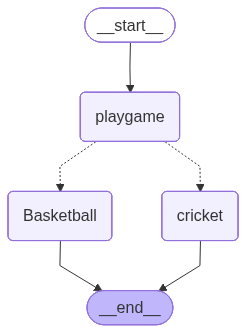

In [12]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
graph.invoke({'name':"Arun"})

-- Playgame Node call --
==Basketball callled==


{'name': 'Arunwant to play ', 'game': 'Basketball'}